<div align="center">

<h1> <b> ESTADÍSTICA DE POISSON Y DISTRIBUCIONES DE PROBABILIDAD APLICADAS </b> </h1>

</div>

<br>

<hr size=10 noshade color="green">
<p>
<p><img alt="UdeA logo" height="180px" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="left" hspace="100px" vspace="4px"></p>

<div align="right">       

<h3><i> <b>Cristian Vergara Restrepo <br>
Santiago Ramírez Gaviria</b> <br>  
Universidad de Antioquia <br>
Instituto de Física  <br>
</i></h3>
</div>

---


# Estadística de Poisson: tubo escintilador

**Física Experimental IV**

## Resumen

El propósito de esta práctica es analizar el comportamiento de un tubo escintilador y extraer conclusiones a partir de un análisis estadístico basado en la distribución de Poisson.

**Materiales:** cronómetro, tubo escintilador, fuente radiactiva, amplificador y cuaderno de protocolo.

## Actividad

Un tubo escintilador es un instrumento que permite detectar radiación ionizante. Usualmente está compuesto de dos partes: un escintilador y un fotomultiplicador. El escintilador contiene un material luminiscente que emite fotones al ser impactado por radiación ionizante; estos fotones se producen por fluorescencia, por fosforescencia o por una combinación de ambos fenómenos (Knoll, 2010). Dado que la cantidad de fotones emitidos por cada evento de ionización es baja, se acopla un fotomultiplicador que convierte ese número reducido de fotones en una señal electrónica fácil de medir.

A pesar de la sensibilidad de los tubos escintiladores, antes de poder medir una muestra o un fenómeno específico es necesario cuantificar la radiación de fondo, con el fin de separarla de la señal de interés. Esta radiación de fondo proviene de diversas fuentes, entre las que destacan los rayos cósmicos.

Los sucesos en los que un número alto de eventos posibles tiene una probabilidad muy baja de ocurrir en cada intervalo de tiempo (p ≪ 1), como el decaimiento radiactivo, se ajustan a la estadística de Poisson (Taylor, 1997).

El procedimiento experimental consta de tres etapas:

1. Para determinar el fondo de radiación del escintilador, se opera el detector en su modo estándar. Se mide con un cronómetro el intervalo de tiempo promedio necesario para alcanzar un número fijo de conteos (repitiendo la medición varias veces para promediar), y luego se realizan 30 medidas adicionales usando ese intervalo, registrando el número de conteos obtenido en cada una.
2. Se construye un histograma del número de conteos por intervalo frente a su frecuencia. La media muestral, obtenida al dividir el total de cuentas entre el número de intervalos medidos, se usa como el parámetro λ de la distribución de Poisson con la que se ajusta el histograma. La calidad del ajuste se evalúa con el criterio de chi-cuadrado.
3. Se acerca la muestra provista al tubo escintilador y se repite el procedimiento, usando los mismos intervalos de tiempo. Comparando la media obtenida con la distribución de Poisson de fondo, se evalúa —con un 95 % de confianza— si la muestra es activa (si presenta un proceso que produce radiación ionizante adicional).


## Desarrollo

### Medición de la radiación de fondo

In [ ]:
import math

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import chi2, binom

# Tiempos (en segundos) medidos en 10 repeticiones para alcanzar 10 conteos
# de fondo; su promedio define la duración de los intervalos que se usan
# en el resto del experimento.
times = [18.73, 12.61, 11.11, 6.08, 22.00, 7.13, 15.03, 10.81, 8.78, 13.88]
average_time = np.mean(times)
print(f"Tiempo promedio necesario para 10 conteos: {average_time:.2f} s")


Tiempo promedio necesario para 10 conteos: 12.62 s


In [ ]:
# Número de conteos de fondo registrados en 30 intervalos de duración
# igual a `average_time` (~12.6 s).
counts = [10, 10, 9, 13, 9, 13, 14, 11, 11, 9, 15, 10, 10, 9, 14, 11, 11, 13, 12, 8,
          10, 8, 12, 11, 17, 7, 12, 9, 11, 12]

# La media muestral estima el parámetro lambda de la distribución de Poisson.
lam_background = np.mean(counts)
print(f"Media de las detecciones de fondo (lambda): {lam_background:.2f}")


Media de las detecciones de fondo (lambda): 11.03


In [ ]:
def poisson_pmf(k, lam):
    """Probabilidad de observar exactamente k eventos bajo una
    distribución de Poisson de parámetro lam (masa de probabilidad
    puntual)."""
    return math.exp(-lam) * lam**k / math.factorial(k)


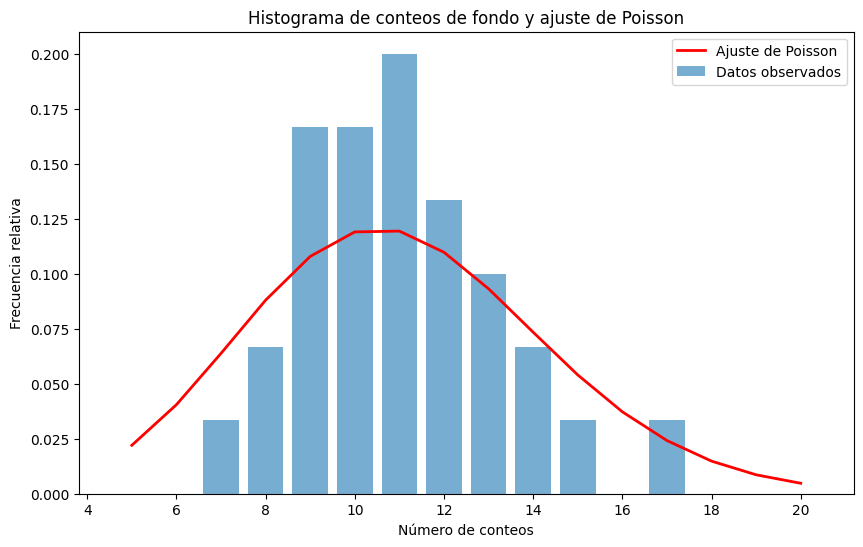

In [ ]:
# Se compara el histograma normalizado de los conteos observados con la
# distribución de Poisson ajustada, en el rango de valores con frecuencia
# apreciable.
list_k = list(range(5, 21))
poisson_fit = [poisson_pmf(k, lam_background) for k in list_k]
histogram = [counts.count(k) / len(counts) for k in list_k]

plt.figure(figsize=(10, 6))
plt.bar(list_k, histogram, alpha=0.6, label='Datos observados')
plt.plot(list_k, poisson_fit, 'r-', linewidth=2, label='Ajuste de Poisson')
plt.xlabel('Número de conteos')
plt.ylabel('Frecuencia relativa')
plt.title('Histograma de conteos de fondo y ajuste de Poisson')
plt.legend()
plt.show()


### Prueba de bondad de ajuste (chi-cuadrado)

Se evalúa si la distribución de Poisson ajustada describe adecuadamente los datos observados mediante el criterio de chi-cuadrado (Taylor, 1997), comparando las frecuencias observadas con las esperadas bajo el modelo.

In [ ]:
observed = np.array([counts.count(k) for k in list_k])
expected = np.array([poisson_pmf(k, lam_background) * len(counts) for k in list_k])

chi_squared = np.sum((observed - expected)**2 / expected)
# Grados de libertad: número de categorías (bins) menos uno. No se resta un
# grado adicional por la estimación de lambda a partir de los propios
# datos, una simplificación habitual a este nivel del curso.
dof = len(list_k) - 1
chi_squared_critical = chi2.ppf(0.95, dof)

print(f"Valor de chi-cuadrado: {chi_squared:.2f}")
print(f"Valor crítico de chi-cuadrado (95%, {dof} g.l.): {chi_squared_critical:.2f}")

if chi_squared < chi_squared_critical:
    print("El ajuste de Poisson es adecuado según el criterio de chi-cuadrado.")
else:
    print("El ajuste de Poisson no es adecuado según el criterio de chi-cuadrado.")


Valor de chi-cuadrado: 8.12
Valor crítico de chi-cuadrado (95%, 15 g.l.): 25.00
El ajuste de Poisson es adecuado según el criterio de chi-cuadrado.


### Evaluación de la actividad de la muestra

Se repite el conteo con la muestra radiactiva acercada al tubo escintilador, usando los mismos intervalos de 12.6 s. Varios de los conteos registrados resultan extremadamente altos (cientos o miles de cuentas en un único intervalo), valores atípicos frente al resto de la muestra que distorsionan fuertemente su media y su desviación estándar. Por ello, la prueba de hipótesis se realiza tanto con el conjunto completo de datos como excluyendo dichos valores atípicos, para evaluar qué tan sensible es la conclusión a su presencia.

In [ ]:
radiative_counts = [17, 10, 11, 21, 20, 11, 11, 14, 13, 10, 10, 15, 16, 11, 732, 11, 6, 10, 14, 10,
                    6, 9, 12, 9, 14, 16, 166, 1217, 3964, 1511, 8, 18, 9, 17, 11]


def z_test_mean(sample, mu0, z_critical=1.96):
    """Prueba z de dos colas para la media de `sample` frente al valor de
    referencia mu0, con 95% de confianza. Devuelve la media, la
    desviación estándar muestral, el estadístico z y si la diferencia es
    significativa."""
    sample = np.asarray(sample, dtype=float)
    mean = sample.mean()
    std = sample.std(ddof=1)
    z = (mean - mu0) / (std / np.sqrt(sample.size))
    return mean, std, z, abs(z) > z_critical


# Prueba usando el conjunto completo de datos.
mean_full, std_full, z_full, active_full = z_test_mean(radiative_counts, lam_background)
print("Con todos los datos:")
print(f"  Media = {mean_full:.2f}, desviación estándar = {std_full:.2f}, z = {z_full:.2f}")
print(f"  ¿Muestra activa (95% confianza)? {'Sí' if active_full else 'No'}")

# Los valores atípicos (> 100 cuentas) resultan muy poco probables bajo la
# distribución de Poisson de fondo y probablemente corresponden a eventos
# espurios de conteo (p. ej. ruido electrónico), no a la tasa estacionaria
# de la muestra; se excluyen para una segunda prueba, más robusta.
outliers = [c for c in radiative_counts if c > 100]
clean_counts = [c for c in radiative_counts if c <= 100]
mean_clean, std_clean, z_clean, active_clean = z_test_mean(clean_counts, lam_background)
print("\nExcluyendo valores atípicos", outliers, ":")
print(f"  Media = {mean_clean:.2f}, desviación estándar = {std_clean:.2f}, z = {z_clean:.2f}")
print(f"  ¿Muestra activa (95% confianza)? {'Sí' if active_clean else 'No'}")


Con todos los datos:
  Media = 227.43, desviación estándar = 732.35, z = 1.75
  ¿Muestra activa (95% confianza)? No

Excluyendo valores atípicos [732, 166, 1217, 3964, 1511] :
  Media = 12.33, desviación estándar = 3.82, z = 1.87
  ¿Muestra activa (95% confianza)? No


### Análisis y conclusiones

**Radiación de fondo**

El tiempo promedio necesario para alcanzar 10 conteos de fondo fue de aproximadamente 12.6 s. A partir de 30 mediciones adicionales realizadas con esa duración, la media de conteos por intervalo resultó de aproximadamente 11.0, valor que se usó como el parámetro λ de la distribución de Poisson ajustada al histograma de frecuencias observadas.

La prueba de chi-cuadrado, con un valor calculado muy por debajo del valor crítico al 95 % de confianza, confirma que el modelo de Poisson describe adecuadamente el comportamiento de la radiación de fondo del tubo escintilador.

**Evaluación de la muestra**

Al acercar la muestra provista al detector, varios de los conteos registrados en los 35 intervalos medidos resultaron extremadamente altos (hasta cerca de 4000 cuentas en un solo intervalo), muy por encima del resto de las mediciones. Estos valores distorsionan fuertemente la media y la desviación estándar de la muestra completa.

La prueba z de dos colas al 95 % de confianza, tanto usando el conjunto completo de datos como excluyendo los valores atípicos, no encuentra evidencia estadísticamente significativa de que la media de conteos con la muestra difiera de la radiación de fondo. Es decir, con la información disponible no puede concluirse que la muestra provista sea activa.

**Conclusiones generales**

1. La radiación de fondo del tubo escintilador se ajusta adecuadamente a una distribución de Poisson de parámetro λ ≈ 11.0, según el criterio de chi-cuadrado.
2. Los conteos obtenidos con la muestra provista incluyen valores atípicos extremos que probablemente corresponden a eventos espurios de conteo y no a la tasa estacionaria del proceso. Al considerarlos o al excluirlos, la prueba de hipótesis no muestra evidencia suficiente de actividad radiactiva en la muestra.
3. El experimento evidencia la utilidad de la distribución de Poisson y de las pruebas de bondad de ajuste para caracterizar la radiación de fondo en experimentos de conteo de baja tasa, y la importancia de tratar adecuadamente los valores atípicos al analizar mediciones de este tipo.


### Ejercicios

A continuación se resuelven distintos problemas de probabilidad y estadística aplicada, empleando las distribuciones binomial y de Poisson, así como pruebas de hipótesis para la media, siguiendo los procedimientos estándar descritos en Walpole et al. (2012).

- <font color='#2E9AFE'>**Ejercicio 1**</font>

La probabilidad de que a un cliente nuevo le guste la hamburguesa de Jorge es de 0.8. Si llegan 5 clientes nuevos a la cafetería, ¿cuál es la probabilidad de que solo a (0, 1, 2, 3, 4, 5) de ellos les guste la hamburguesa? Dibuje la gráfica resultante.

<font color='#FF4000'>**Solución:**</font>

Este problema se modela usando una distribución binomial:

$$
P(x = k) = \binom{n}{k} p^{k}q^{n-k}
$$

donde $n=5$, $p=0.8$, $q=0.2$ y $k=0,\dots,5$, con lo cual se obtienen los siguientes resultados:

$P(x=0) = 0.00032$

$P(x=1) = 0.0064$

$P(x=2) = 0.0512$

$P(x=3) = 0.2048$

$P(x=4) = 0.4096$

$P(x=5) = 0.32768$

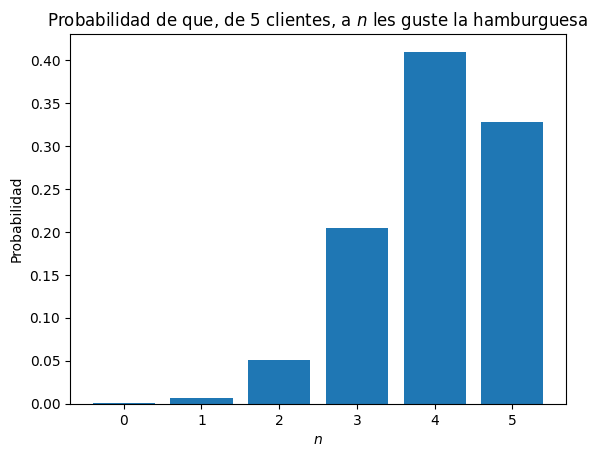

In [ ]:
# Número de clientes a los que les gusta la hamburguesa, de 5 clientes
# nuevos, con probabilidad de éxito individual p = 0.8.
n, p = 5, 0.8
x_values = list(range(n + 1))
probabilities = [binom.pmf(k, n, p) for k in x_values]

plt.bar(x_values, probabilities)
plt.title(r'Probabilidad de que, de 5 clientes, a $n$ les guste la hamburguesa')
plt.xlabel(r'$n$')
plt.ylabel('Probabilidad')
plt.show()


---

- <font color='#2E9AFE'>**Ejercicio 2**</font>

De todas las flores plantadas por una empresa de jardinería, el 90 % sobrevive. Si se plantan 10 flores, ¿cuál es la probabilidad de que 7 o más sobrevivan?

<font color='#FF4000'>**Solución:**</font>

En este caso se debe usar la distribución binomial y sumar las probabilidades desde $x=7$ hasta $x=10$, es decir:

$$
P(x \geq 7) = \sum_{k=7}^{10} \binom{10}{k} p^{k}q^{10-k}
$$

donde $p=0.9$ y $q=0.1$, lo que da como resultado:

$P(x \geq 7) = 0.9872$

In [ ]:
p_ge_7 = binom.cdf(10, 10, 0.9) - binom.cdf(6, 10, 0.9)
print(f"P(x >= 7) = {p_ge_7:.4f}")


P(x >= 7) = 0.9872


---

- <font color='#2E9AFE'>**Ejercicio 3**</font>

La probabilidad de que un estudiante seleccionado al azar apruebe cierto examen de física es de 0.2. Sea $X$ = el número de estudiantes que aprueban el examen en una muestra aleatoria de tamaño $n=8$; calcule la probabilidad de que aprueben entre 2 y 6 estudiantes.

<font color='#FF4000'>**Solución:**</font>

Igualmente se utiliza la distribución binomial y su función de probabilidad acumulada. Puesto que el suceso debe incluir $x=2$, la probabilidad se obtiene como:

$$
P(2 \leq x \leq 6) = \sum_{k=2}^{6} \binom{8}{k} p^{k}q^{8-k} = P(x \leq 6) - P(x \leq 1)
$$

donde $p=0.2$ y $q=0.8$, lo que da como resultado:

$$
P(2 \leq x \leq 6) = 0.4966
$$

In [ ]:
# P(2 <= x <= 6) = P(x <= 6) - P(x <= 1); se resta hasta x=1 para que el
# resultado incluya el caso x=2.
p_2_to_6 = binom.cdf(6, 8, 0.2) - binom.cdf(1, 8, 0.2)
print(f"P(2 <= x <= 6) = {p_2_to_6:.4f}")


P(2 <= x <= 6) = 0.4966


---

- <font color='#2E9AFE'>**Ejercicio 4**</font>

En los últimos 600 años se han producido 12 grandes terremotos en España. ¿Cuál es la probabilidad de que se produzcan 2 en los próximos 25 años?

<font color='#FF4000'>**Solución:**</font>

Este problema se puede describir mediante una distribución de Poisson:

$$
P(x=k) = \frac{e^{-\lambda}\lambda^{k}}{k!}
$$

Aplicando una regla de tres se calcula la tasa de terremotos esperada en un periodo de 25 años:

$$
\frac{12}{600} = \frac{n}{25} \longrightarrow n = 0.5 = \lambda
$$

de modo que la probabilidad de que ocurran 2 terremotos en 25 años es:

$$
P(x=2) = \dfrac{e^{-0.5}0.5^{2}}{2!} = 0.0758
$$

---

- <font color='#2E9AFE'>**Ejercicio 5**</font>

En una estación de montaña se han observado 20 días con altura de nieve mayor que $h$ durante un periodo de 10 años. Calcule la probabilidad de superar dicho valor $h$ una vez en los próximos 3 años.

<font color='#FF4000'>**Solución:**</font>

Este problema se puede describir mediante una distribución de Poisson:

$$
P(x=k) = \frac{e^{-\lambda}\lambda^{k}}{k!}
$$

Aplicando una regla de tres se calcula la frecuencia de días esperada en un periodo de 3 años:

$$
\frac{20}{10} = \frac{n}{3} \longrightarrow n = 6 = \lambda
$$

de modo que la probabilidad de que en 3 años se registre un día con una altura superior a $h$ es:

$$
P(x=1) = \dfrac{e^{-6}6^{1}}{1!} = 0.01487
$$

---

- <font color='#2E9AFE'>**Ejercicio 6**</font>

Un banco recibe en promedio 6 cheques falsos al día. Calcule la probabilidad de que se reciban 5 cheques falsos en un día.

<font color='#FF4000'>**Solución:**</font>

Usando la distribución de Poisson:

$$
P(x=5) = \dfrac{e^{-6}6^{5}}{5!} = 0.1606
$$

---

- <font color='#2E9AFE'>**Ejercicio 7**</font>

Una compañía aérea observa que el número promedio de componentes que fallan antes de cumplir 100 horas de funcionamiento es 8. Se pide:

**a)** ¿Cuál es la probabilidad de que falle un componente en 25 horas?

**b)** ¿Cuál es la probabilidad de que fallen menos de dos componentes en 50 horas?

**c)** ¿Cuál es la probabilidad de que fallen por lo menos tres componentes en 125 horas?

<font color='#FF4000'>**Solución:**</font>

Para los tres literales se usa la distribución de Poisson.

**a)** El promedio de fallos en 25 horas, por regla de tres, es:

$$
\frac{8}{100} = \frac{n}{25} \longrightarrow n = 2 = \lambda
$$

$$
P(x=1) = \dfrac{e^{-2}2^{1}}{1!} = 0.2706
$$

**b)** El promedio de fallos en 50 horas es:

$$
\frac{8}{100} = \frac{n}{50} \longrightarrow n = 4 = \lambda
$$

Sumando la probabilidad de que fallen 0 o 1 componentes:

$$
P(x < 2) = \dfrac{e^{-4}4^{0}}{0!} + \dfrac{e^{-4}4^{1}}{1!} = 0.0916
$$

**c)** El promedio de fallos en 125 horas es:

$$
\frac{8}{100} = \frac{n}{125} \longrightarrow n = 10 = \lambda
$$

Debe calcularse $P(x \geq 3)$, lo cual es equivalente a:

$$
P(x \geq 3) = 1 - P(x < 3) = 1 - \left( \dfrac{e^{-10}10^{0}}{0!} + \dfrac{e^{-10}10^{1}}{1!} + \dfrac{e^{-10}10^{2}}{2!} \right) = 0.9972
$$

---

- <font color='#2E9AFE'>**Ejercicio 8**</font>

Un estudio de 29 familias de una zona residencial de una ciudad de Colombia revela que el ingreso medio por familia durante 2011 fue de 808.000, con una desviación estándar de 16.000. Evalúe la hipótesis de que el verdadero ingreso medio por familia durante 2011 fue de 800.000 frente a la alternativa de que no fue de 800.000, usando un nivel de significancia del 5 %.

<font color='#FF4000'>**Solución:**</font>

Como se quiere evaluar si el ingreso medio es distinto de 800.000 (y no específicamente mayor o menor), se plantea una prueba de hipótesis de dos colas:

$$
H_0: \mu = 800.000, \qquad H_a: \mu \neq 800.000
$$

Al tratarse de una muestra, el estadístico de prueba es:

$$
Z = \frac{\bar{x} - \mu_0}{\sigma/\sqrt{n}} = \frac{808.000 - 800.000}{16.000/\sqrt{29}} \approx 2.69
$$

Al ser una prueba de dos colas con $\alpha=0.05$, se compara con $Z_{0.025}=1.96$:

$$
|Z| = 2.69 > 1.96 = Z_{0.025}
$$

**Conclusión:** con un nivel de significancia del 5 %, existe evidencia suficiente para rechazar la hipótesis de que el ingreso medio por familia en 2011 fue de 800.000.

In [ ]:
# Datos del problema
mu0 = 800_000    # Ingreso medio bajo la hipótesis nula
x_bar = 808_000   # Ingreso medio muestral
sigma = 16_000     # Desviación estándar poblacional
n = 29              # Tamaño de la muestra
alpha = 0.05         # Nivel de significancia

# Prueba de dos colas: H0: mu = 800.000   Ha: mu != 800.000
z = (x_bar - mu0) / (sigma / np.sqrt(n))
z_critical = stats.norm.ppf(1 - alpha / 2)

print(f"Estadístico z: {z:.4f}")
print(f"Valor crítico (dos colas, alpha={alpha}): {z_critical:.4f}")
print("Se rechaza H0." if abs(z) > z_critical else "No se rechaza H0.")


Estadístico z: 2.6926
Valor crítico (dos colas, alpha=0.05): 1.9600
Se rechaza H0.


---

- <font color='#2E9AFE'>**Ejercicio 9**</font>

Un fabricante de baterías afirma que la capacidad promedio de cierto tipo de batería, producida por la compañía, es de al menos 140 Ah. Una agencia independiente de protección al consumidor desea probar la credibilidad de la afirmación del fabricante y mide la capacidad de una muestra aleatoria de 20 baterías tomadas de un lote producido recientemente. Los resultados, en Ah, son:

137.4, 140, 138.8, 139.1, 144.4, 139.2, 141.8, 137.3, 133.5, 138.2, 141.1, 139.7, 136.7, 136.3, 135.6, 138.0, 140.9, 140.6, 136.7, 134.1

La agencia busca verificar si la afirmación del fabricante (capacidad $\geq$ 140 Ah) es creíble o si resulta exagerada.

<font color='#FF4000'>**Solución:**</font>

Se toma como hipótesis nula la afirmación del fabricante:

$$
H_0: \mu \geq 140 \text{ Ah}, \qquad H_a: \mu < 140 \text{ Ah}
$$

Al tratarse de una muestra pequeña y desconocerse la desviación estándar poblacional, se usa el estadístico $T$ con la desviación estándar muestral $S$:

$$
T = \frac{\bar{x} - \mu_0}{S/\sqrt{n}}
$$

con $\bar{x} \approx 138.47$ Ah y $S \approx 2.66$ Ah, lo que da $T \approx -2.57$. El valor crítico para una prueba de una cola con 19 grados de libertad y $\alpha=0.05$ es:

$$
T_{19,\,0.05} = 1.7291
$$

**Conclusión:** como $|T| = 2.57 > 1.7291$, se rechaza $H_0$: hay evidencia suficiente, con un 5 % de significancia, para concluir que la capacidad media real es menor que la afirmada por el fabricante.

In [ ]:
battery_capacities = [137.4, 140, 138.8, 139.1, 144.4, 139.2, 141.8, 137.3, 133.5, 138.2,
                      141.1, 139.7, 136.7, 136.3, 135.6, 138.0, 140.9, 140.6, 136.7, 134.1]

mu0 = 140  # Capacidad mínima media afirmada por el fabricante (Ah)
n = len(battery_capacities)
mean_capacity = np.mean(battery_capacities)
std_capacity = np.std(battery_capacities, ddof=1)  # desviación estándar muestral

t_stat = (mean_capacity - mu0) / (std_capacity / np.sqrt(n))
t_critical = stats.t.ppf(0.95, n - 1)

print(f"Media muestral: {mean_capacity:.2f} Ah")
print(f"Desviación estándar muestral: {std_capacity:.2f} Ah")
print(f"Estadístico T: {t_stat:.4f}")
print(f"Valor crítico T({n - 1}, 0.05): {t_critical:.4f}")
print("Se rechaza H0." if abs(t_stat) > t_critical else "No se rechaza H0.")


Media muestral: 138.47 Ah
Desviación estándar muestral: 2.66 Ah
Estadístico T: -2.5734
Valor crítico T(19, 0.05): 1.7291
Se rechaza H0.


---

- <font color='#2E9AFE'>**Ejercicio 10**</font>

La duración de las bombillas de 100 W que fabrica una empresa sigue una distribución normal con una desviación estándar de 120 horas. Su vida media está garantizada en un mínimo de 800 horas. Se escoge al azar una muestra de 50 bombillas de un lote y, tras comprobarlas, se obtiene una vida media de 750 horas. Con un nivel de significancia de 0.01, ¿habría que rechazar el lote por no cumplir la garantía?

<font color='#FF4000'>**Solución:**</font>

Se plantea una prueba de una cola:

$$
H_0: \mu \geq 800, \qquad H_a: \mu < 800
$$

con el estadístico:

$$
Z = \frac{\bar{x}-\mu_0}{\sigma/\sqrt{n}}
$$

In [ ]:
# Datos del problema
mu0 = 800     # Vida media garantizada (horas)
sigma = 120    # Desviación estándar poblacional (horas)
n = 50          # Tamaño de la muestra
x_bar = 750     # Vida media muestral (horas)
alpha = 0.01     # Nivel de significancia

# Prueba de una cola: H0: mu >= 800   Ha: mu < 800
z = (x_bar - mu0) / (sigma / n ** 0.5)
z_critical = stats.norm.ppf(alpha)

print(f"Estadístico z: {z:.4f}")
print(f"Valor crítico: {z_critical:.4f}")
print("Se rechaza el lote." if z < z_critical else "No se rechaza el lote.")


Estadístico z: -2.9463
Valor crítico: -2.3263
Se rechaza el lote.


**Conclusión:** con un nivel de significancia del 0.01, hay suficiente evidencia para rechazar el lote de bombillas, porque su vida media es significativamente menor a 800 horas, incumpliendo la garantía.

---

- <font color='#2E9AFE'>**Ejercicio 11**</font>

Una empresa eléctrica fabrica baterías de celular cuya duración se distribuye de forma aproximadamente normal, con una media de 800 horas y una desviación estándar de 40 horas. Una muestra aleatoria de 30 baterías tiene una duración promedio de 785 horas. ¿Muestran los datos suficiente evidencia para decir que la duración media es menor a 800 horas? Utilice un nivel de significancia del 5 %.

<font color='#FF4000'>**Solución:**</font>

Se plantea una prueba de una cola:

$$
H_0: \mu \geq 800, \qquad H_a: \mu < 800
$$

con el estadístico:

$$
Z = \frac{\bar{x}-\mu_0}{\sigma/\sqrt{n}}
$$

In [ ]:
# Datos del problema
mu0 = 800     # Media poblacional (horas)
sigma = 40     # Desviación estándar poblacional (horas)
n = 30          # Tamaño de la muestra
x_bar = 785     # Media muestral (horas)
alpha = 0.05     # Nivel de significancia

# Prueba de una cola: H0: mu >= 800   Ha: mu < 800
z = (x_bar - mu0) / (sigma / n ** 0.5)
z_critical = stats.norm.ppf(alpha)

print(f"Estadístico z: {z:.4f}")
print(f"Valor crítico: {z_critical:.4f}")
print("Hay evidencia suficiente para decir que mu < 800." if z < z_critical else "No hay evidencia suficiente.")


Estadístico z: -2.0540
Valor crítico: -1.6449
Hay evidencia suficiente para decir que mu < 800.


**Conclusión:** con un nivel de significancia del 5 %, hay suficiente evidencia para decir que la duración media de las baterías es menor a 800 horas.

---

## Referencias

- Knoll, G. F. (2010). *Radiation detection and measurement* (4th ed.). Wiley.
- Taylor, J. R. (1997). *An introduction to error analysis: The study of uncertainties in physical measurements* (2nd ed.). University Science Books.
- Walpole, R. E., Myers, R. H., Myers, S. L., & Ye, K. (2012). *Probability and statistics for engineers and scientists* (9th ed.). Prentice Hall.